In [152]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt

In [153]:
orders = pd.read_csv("../data/raw/orders.csv")
products = pd.read_csv("../data/raw/products.csv")

#order_lines has bad lines
bad_lines_list = []
order_lines = pd.read_csv("../data/raw/order_lines.csv", engine="python", on_bad_lines = lambda x: bad_lines_list.append(x) or None)
print(f"There are {len(bad_lines_list)} bad lines, and there will be dropped.")
order_lines = order_lines = pd.read_csv("../data/raw/order_lines.csv",on_bad_lines="skip")  

There are 452 bad lines, and there will be dropped.


* 452 bad lines from order_lines table, which have 9 columns instead of 8 are dropped.

In [154]:
print(f"The memory usage of orders table was {(orders.memory_usage().sum()/1024).round(2)} KB.")
print(f"The memory usage of products table was {(products.memory_usage().sum()/1024).round(2)} KB.")
print(f"The memory usage of order_lines table was {(order_lines.memory_usage().sum()/1024).round(2)} KB")


The memory usage of orders table was 1125.69 KB.
The memory usage of products table was 5.99 KB.
The memory usage of order_lines table was 2984.69 KB


In [155]:
# -----DATA TYPES-------------

# CHANGING FOR ORDERS
orders_type_mapping = {
    "order_id": "int32",
    "channel": "category",
    "region": "category",
    "order_total":"float32",
    "num_items": "int16"
}
orders = (
    orders.astype(orders_type_mapping)
          .assign(
              order_date = pd.to_datetime(orders['order_date'])
    )
)

print(f"The size of the new Orders table become {(orders.memory_usage().sum()/1024).round(2)} KB.")
#  CHANGING FOR PRODUCTS
products['unit_cost'] = products['unit_cost'].str.replace(",",".")
products_type_mapping = { 
    'category': "category",
    "unit_price":"float32",
    "unit_cost": "float32"
}
products = ( products.astype(products_type_mapping))
print(f"The size of new Products table become {(products.memory_usage().sum()/1024).round(2)} KB.")

#  CHANGING FOR ORDER_LINES
or_lines_type_mapping = {
    "line_id": "int32",
    "order_id": "int32",
    "product_id":"int32",
    "category": "category"
}
order_lines = order_lines.astype(or_lines_type_mapping)
print(f"The size of new order_lines table become {(order_lines.memory_usage().sum()/1024).round(2)} KB.")


The size of the new Orders table become 633.32 KB.
The size of new Products table become 3.84 KB.
The size of new order_lines table become 2098.7 KB.


* Values from the unit_cost column are touched, to change the "," to ".".
* Data types are changed for simpler analysis and efficient memory usage.

In [156]:
# ----Engineered Columns------------------

# shipping promotion period from the dates that the orders are done
orders['shipping_promotion_period'] = orders['order_date'].dt.month_name()
# the conditions using lists of month names

conditions = [
    orders['shipping_promotion_period'].isin(["January", "February", "March", "April", "May", "June"]),
    orders['shipping_promotion_period'].isin(["July", "August", "September"])
]

# the labels
choices = ["before", "on_promotion"]

# Assigning new values to the columns based on conditions
orders['shipping_promotion_period'] = np.select(conditions, choices, default="Unknown")


* Shipping promotion period column is engineered for adding flexibility on analysis. 

In [157]:
# ----Duplicated Rows--------------
if (orders['order_id'].duplicated().any()):
    print(f"Ohh! There are {orders['order_id'].duplicated().sum()} duplicated rows.")
else:
    print(f"Good to go! There is no duplicated row in orders table.")
 
# ORDER_LINES 
if(order_lines['line_id'].duplicated().any()):
    print(f"Unfortunately! There are {order_lines['line_id'].duplicated().sum()} rows with the same line_id, and will be dropped.")
else: 
    print(f"Good to go! There is no duplicated row in order_lines table.")

order_lines[order_lines['line_id'].duplicated(keep=False)].sort_values(by=['line_id'])
order_lines = order_lines.drop_duplicates(subset='line_id')

# PRODUCTS
if(products['product_id'].duplicated().any()):
    print(f"Unfortunately! There are {products['product_id'].duplicated().sum()} rows with the same product_id, and will be dropped.")
else: 
    print(f"Good to go! There is no duplicated row in products table.")


Good to go! There is no duplicated row in orders table.
Unfortunately! There are 220 rows with the same line_id, and will be dropped.
Good to go! There is no duplicated row in products table.


`220` rows in `order_lines` table with the same `line_id` were dropped.

In [158]:
# ------Missing Values---------------
# ORDERS TABLE
# Based on the information from the business, shipping cost from Jan - June was always €5.95.
# but between starting from July the shipping cost was free for orders more than €50.


# defining the conditions only for rows where shipping cost is missing
is_missing = orders['shipping_cost'].isna()

condition_jan_june = is_missing & (orders['shipping_promotion_period'] == "before")
condition_july_free = is_missing & (orders['shipping_promotion_period'] == "on_promotion") & (orders['order_total'] > 50)
condition_july_paid = is_missing & (orders['shipping_promotion_period'] == "on_promotion") & (orders['order_total'] <= 50)

# Group conditions and their corresponding values
conditions = [condition_jan_june, condition_july_free, condition_july_paid]
choices = [5.95, 0.00, 5.95]

# ----Engineered Column------------------
orders['shipping_cost'] = np.select(conditions, choices, default=orders['shipping_cost'])

print(f"There is {orders['shipping_cost'].isna().sum()} missing values in orders table.")
print(f"There is {products.isna().any().sum()} missing values from products table.")
print(f"There is {order_lines.isna().any().sum()} columns with missing values from order_lines table.")


There is 0 missing values in orders table.
There is 0 missing values from products table.
There is 2 columns with missing values from order_lines table.


* Based on the information from the assignment.md, missed shipping values are filled.
* And for there are missing values on the `unit_price` and `order_lines` 
    that will be fixed my `merging` `orders` table and `order_lines` table.

* unit_price can be filled first merged two tables orders and order_lines.
* ordertotal-line_total

In [159]:
print(f"{order_lines.isna().sum()}")

line_id           0
order_id          0
product_id        0
product_name      0
category          0
quantity          0
unit_price      927
line_total      927
dtype: int64


---

## Merging the tables

In [160]:
# JOining the tables for extra analysis information
# Merging order table and order_lines under the common order_id, to fill the missed value of unit_cost in order_lines.

merged = orders.merge(order_lines,how='inner', on='order_id')
print(f"Order and Order_lines are successfully merged on order_id.")

# Merging the merged table from(order and order_lines ) ane product table on the product id to calculate the profit margin. 

mr = merged.merge(products,how='inner', suffixes=("_mr","_pr"), on='product_id')
mr['profit_margin'] = ((mr['unit_price_mr'] - mr['unit_cost'])*mr['quantity']).round(2)
print(f"merged table and products are successfully merged on product id.")

#Dropping similar columns and saving the final cleaned csv file. 
mr = mr.drop(columns=["category_pr","unit_price_pr","product_name_pr"])
mr.to_csv("../data/processed/cleaned_merged_all.csv")


Order and Order_lines are successfully merged on order_id.
merged table and products are successfully merged on product id.


---

In [162]:
# first fill the missing values with 0 to make the calculation possible
# generate tempo parallel column of line_total 
merged['line_total_filled'] = merged['line_total'].fillna(0)

# generate tempo column of sum of total known price of the items 
merged['total_known_items'] = merged.groupby('order_id')['line_total_filled'].transform(sum).round(2)

calculated_line_total = merged['order_total'] - merged['shipping_cost'] - merged['total_known_items']
merged['unit_price'] = merged['unit_price'].fillna(calculated_line_total/merged['quantity']).round(2)
merged['line_total'] = merged['unit_price'] * merged['quantity']
# dropping the temporary columns
merged = merged.drop(columns=["line_total_filled", "total_known_items"])

if (merged.isna().any().any()):
    print(f"The is {merged.isna().sum()} missing values in the merged tables.")
else:
    print("Good to go! There is no missing values.")

Good to go! There is no missing values.


*  first order table and order_lines table merged.
* order_total is summation of shipping cost and all items unit_price * their quantity.
* the missed unit_price of the items is calculated from the above relation.

----
# ----EDA-----

In [163]:
# Grouping and analyzing the volume of the orders made in different promotion period.
on_promotion = mr[mr['shipping_promotion_period'] == "on_promotion"]
before_promotion = mr[mr['shipping_promotion_period'] == "before"]

# picking the unique orders
volume_pcg = ((on_promotion['order_id'].nunique())/(before_promotion['order_id'].nunique()))*100

print(f"In the promotion period, {volume_pcg: .2f}% of the orders from the before period has made.")

merged.groupby('shipping_promotion_period').size()

In the promotion period,  59.43% of the orders from the before period has made.


shipping_promotion_period
before          28169
on_promotion    19364
dtype: int64

* After the promotion the volume of the customers boomed.
* 59.43% of the volume orders from the Before-promotion period has made only in those 3-months of promotion period. 

### * Total order after and before the promotion

In [164]:
rev_pcg = ((on_promotion.drop_duplicates('order_id')['order_total'].sum() / before_promotion.drop_duplicates('order_id')['order_total']
                .sum())*100).round(2)

print(f"The promotion period generated {rev_pcg: .2f}% of the revenue from the before period.")

merged.drop_duplicates('order_id').groupby('shipping_promotion_period')['order_total'].agg(["sum","min","max","mean"]).reset_index()

The promotion period generated  69.67% of the revenue from the before period.

,shipping_promotion_period,sum,min,max,mean
0,before,2397275.75,7.86,1502.439941,212.618698
1,on_promotion,1670105.25,7.86,1700.030029,249.232239


* The total revenue has boomed in the promotion period.
* The average of order_total is higher than the one before the promotion.
* 69.67% of the revenue from the last 6 month period was able to be reached in the promotion period.

## * does The promotion helped people to spend more?

In [165]:
# different spending tiers categorize each spending 
bins = [7.86,50,100,273,360,1000, np.inf]

labels = ["low","threshold","high","very_high","super_high","uncommon"]

# pd.cut great built in method to change continuous data to category 
mr['spending_category'] = pd.cut(mr['order_total'],bins=bins,labels=labels)

spending_pcg = (
    pd.crosstab(mr['spending_category'], mr['shipping_promotion_period'], normalize='columns') * 100
).round(2)

print(spending_pcg)

shipping_promotion_period  before  on_promotion
spending_category                              
low                          6.87          3.52
threshold                   14.31         11.30
high                        42.44         41.68
very_high                   13.65         14.94
super_high                  21.86         27.44
uncommon                     0.88          1.12


spending of the people has been changed because of the promotion.
people tend to spent more than 50euros in each order, they made.

* After the promotion the behavior of the customers changed in some way. They like to add items to their cart to reach the threshold.
* given the the comparison is 6-months period vs 3-months period the outcome is promising, and indeed it help people to spend more than 50 euro.

## * Shipping Revenue and is it covered by the revenue generated?

In [166]:
# Picking and Checking only the revenue from the orders above 50
free_promo = on_promotion[on_promotion['order_total'] > 50].copy()

total_item_revenue = free_promo['line_total'].sum()
total_product_cost = (free_promo['unit_cost'] * free_promo['quantity']).sum()
covered_shipping_cost = free_promo['order_id'].nunique() * 5.95


# The Profit Calculation
net_promo_profit = total_item_revenue - total_product_cost - covered_shipping_cost

print(f"Total Item Revenue:  €{total_item_revenue:,.2f}")
print(f"Total Product Cost:  €{total_product_cost:,.2f}")
print(f"Shipping covered by the company:   €{covered_shipping_cost:,.2f}")
print(f"-----------------------------------")
print(f"Net Promotion Profit: €{net_promo_profit:,.2f}")


Total Item Revenue:  €1,613,058.52
Total Product Cost:  €1,153,687.99
Shipping covered by the company:   €36,610.35
-----------------------------------
Net Promotion Profit: €422,760.18


* Even though `€36,610.35` `shipping cost` covered by the company,
* In the `promotion period` the profit gained only from the above the `50 orders` is `€422,760.18`.
* So the Promotion is real. there is increase in `profit`, increase in `total revenue`, increase in `volume of orders.`

## * comparing the Revenue and the Profit margin of the two periods?

In [167]:
since_july_profit = on_promotion['profit_margin'].sum()
sep_june_profit = before_promotion['profit_margin'].sum()
avg_profit = (since_july_profit / sep_june_profit)*100

print(f"The profit margin of on promotion period: €{since_july_profit: ,.2f}")
print(f"The profit margin of before period: €{sep_june_profit: ,.2f}")
print(f"-----------------------------------")
print(f"{avg_profit: ,.2f}% of the profit from the before period was reached only in the 3-months promotion period.")

The profit margin of on promotion period: € 488,102.17
The profit margin of before period: € 706,683.92
-----------------------------------
 69.07% of the profit from the before period was reached only in the 3-months promotion period.


* Profit margin is increasing. 69% profit of the previous period was gained only in 3 months.

## * Which months has highest revenue and profit margin

In [168]:
mr["order_month"] = mr['order_date'].dt.month_name()
monthly_tot_profit_margin = mr.groupby('order_month')['profit_margin'].sum().sort_values(ascending=False)
monthly_tot_profit_margin

order_month
August       168239.87
July         162303.61
September    157558.69
January      121495.22
June         121255.71
March        117308.27
May          116957.66
April        116940.01
February     112727.05
Name: profit_margin, dtype: float64

* based on profit_margin and total order made metrics the months from the promotion period sit on top.
* the profit is undeniable.

In [169]:
# Getting the df of the pick months in before period
months_of_interest = mr[mr['order_month'].isin(["January", "March", "June"])]

highest_months = months_of_interest.groupby('order_month')

# pm~profit_margin, tr~total_order , JMC~January-march-June, JAS~July-August~Sep
tr_JMJ = months_of_interest.drop_duplicates('order_id')['order_total'].sum()
pm_JMJ = months_of_interest['profit_margin'].sum()
pm_JAS = on_promotion['profit_margin'].sum()
pm_avg = (pm_JMJ/pm_JAS)*100

print(f"The profit made from the highest orders made from before the promotion period is only {pm_avg: ,.2f}% of the profit margin in promotion period.) ")

The profit made from the highest orders made from before the promotion period is only  73.77% of the profit margin in promotion period.) 


* I took 3 highest months from before promotion period, and compare 3 vs 3.
* still the profit margin of during the promotion period wins by 135%

In [170]:
potential_revenue = (len(on_promotion) * 5.95)  + on_promotion["shipping_cost"].sum()
print(f"The potential revenue from the total orders was: {potential_revenue}")

The potential revenue from the total orders was: 119273.7


---

### * Which region has generated highest revenue?

In [171]:
orders_dedup = mr.drop_duplicates('order_id')

region_rev_pct = pd.crosstab(
    index=orders_dedup['region'],
    columns=orders_dedup['shipping_promotion_period'],
    values=orders_dedup['order_total'],
    aggfunc='sum',
    normalize='columns'
).round(2) * 100

print(region_rev_pct)
print("------------------------")
# region profit margin
region_profit_pct = pd.crosstab(
    index=mr['region'],
    columns=mr['shipping_promotion_period'],
    values=mr['profit_margin'],
    aggfunc='sum',
    normalize='columns'
).round(2) * 100
print(region_profit_pct)


shipping_promotion_period     before  on_promotion
region                                            
Central                    20.000000          20.0
East                       20.000000          21.0
North                      25.000000          25.0
South                      20.000000          20.0
West                       15.000001          14.0
------------------------
shipping_promotion_period  before  on_promotion
region                                         
Central                      20.0          20.0
East                         20.0          21.0
North                        25.0          25.0
South                        20.0          19.0
West                         15.0          14.0


* Interestingly all regions has close profit margin and generated revenue.
* So the compony is need to address all the the customers in all regions.

### * The Which channel has generated highest profit?

In [172]:
# 
mr.groupby(['channel','shipping_promotion_period']).size().unstack()
channel_pcg = (
    pd.crosstab(mr['channel'], mr['shipping_promotion_period'], normalize='columns') * 100
).round(2)
print(channel_pcg)
mr.groupby(['channel','shipping_promotion_period'])['profit_margin'].sum().unstack()


shipping_promotion_period  before  on_promotion
channel                                        
marketplace                 10.16         10.88
mobile_app                  35.42         35.05
web                         54.42         54.07


shipping_promotion_period,before,on_promotion
channel,,
marketplace,71766.87,52598.08
mobile_app,250884.34,170559.03
web,384032.71,264945.06


* The profit margin across the all the channels has promising change after the promotion period.
* The Web channel has generated 54% of the profit and the marketplace has generated 10.88%.  

* Profit Margin during and before the promotion period

### * How often product Category has ordered and generated profit from it?  

In [173]:
cat_profit_pct = pd.crosstab(
    index=mr['category_mr'],
    columns=mr['shipping_promotion_period'],
    values=mr['profit_margin'],
    aggfunc='sum',
    normalize='columns'
).round(2) * 100

cat_rev_pct = pd.crosstab(
    index=orders_dedup['category_mr'],
    columns=orders_dedup['shipping_promotion_period'],
    values=orders_dedup['order_total'],
    aggfunc='sum',
    normalize='columns'
).round(2) * 100
print(cat_rev_pct)
print(cat_profit_pct)

shipping_promotion_period  before  on_promotion
category_mr                                    
Beauty & Health              14.0     14.000000
Books                        13.0     12.000000
Clothing & Accessories       14.0     15.000001
Electronics                  28.0     28.000000
Home & Kitchen               14.0     14.000000
Sports & Outdoors            17.0     17.000000
shipping_promotion_period  before  on_promotion
category_mr                                    
Beauty & Health              14.0          14.0
Books                         9.0           9.0
Clothing & Accessories       15.0          15.0
Electronics                  37.0          38.0
Home & Kitchen               12.0          12.0
Sports & Outdoors            13.0          13.0


* looking the amount of order made all products category has similar values, which means they have order all frequently.
* but the profit generated from Electronics is higher 38% while books has generated low profit.
* The promotion has not negative impact at all in all the products and profit.

---

## * Visualization

* Revenue generated during different period.

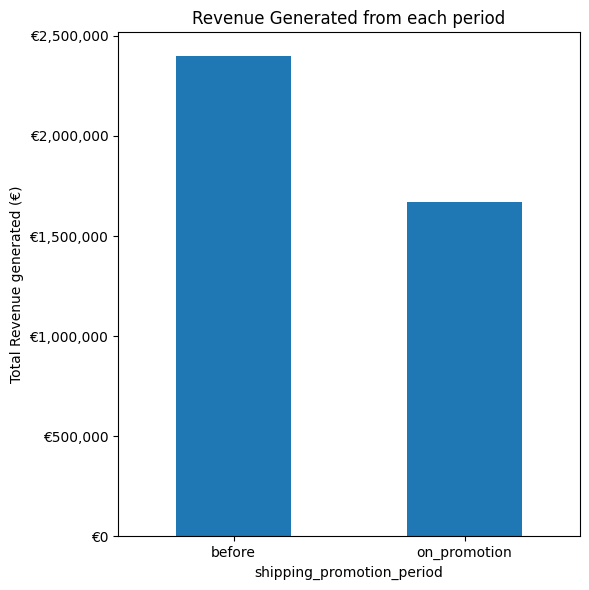

In [174]:
mr.drop_duplicates('order_id').groupby('shipping_promotion_period')['order_total'].sum().plot(
    kind="bar",
    figsize=(6, 6),
    ylabel="Total Revenue generated (€)",
    title="Revenue Generated from each period",
    legend=False, rot=0
)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
plt.tight_layout()
plt.show()

* 69% of revenue from the previous period was generated only in those 3months of promotion period.

* profit margin across the different promotion period

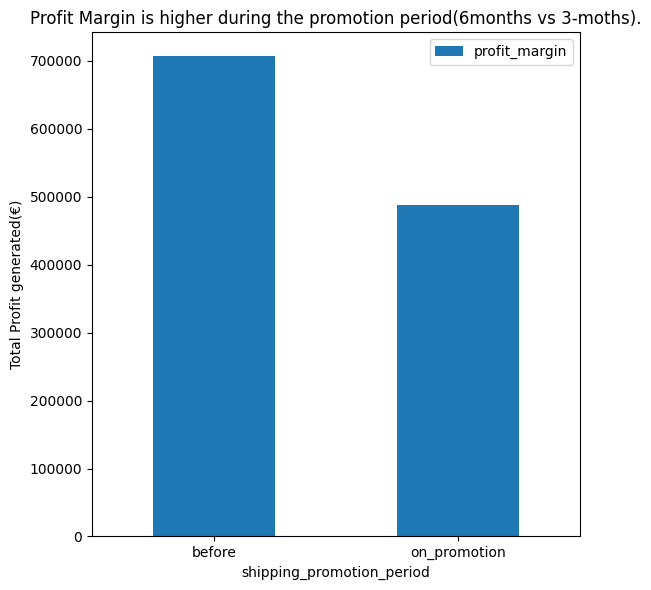

In [175]:
mr.groupby('shipping_promotion_period')['profit_margin'].sum().plot(
    kind="bar",
    figsize=(6,6),
    y="profit_margin",ylabel="Total Profit generated(€)",x = "shipping_promotion_period",title="Profit Margin is higher during the promotion period(6months vs 3-moths).",
    legend=True,rot=0
    )
plt.tight_layout()
plt.show()

* Profit margin across all the months

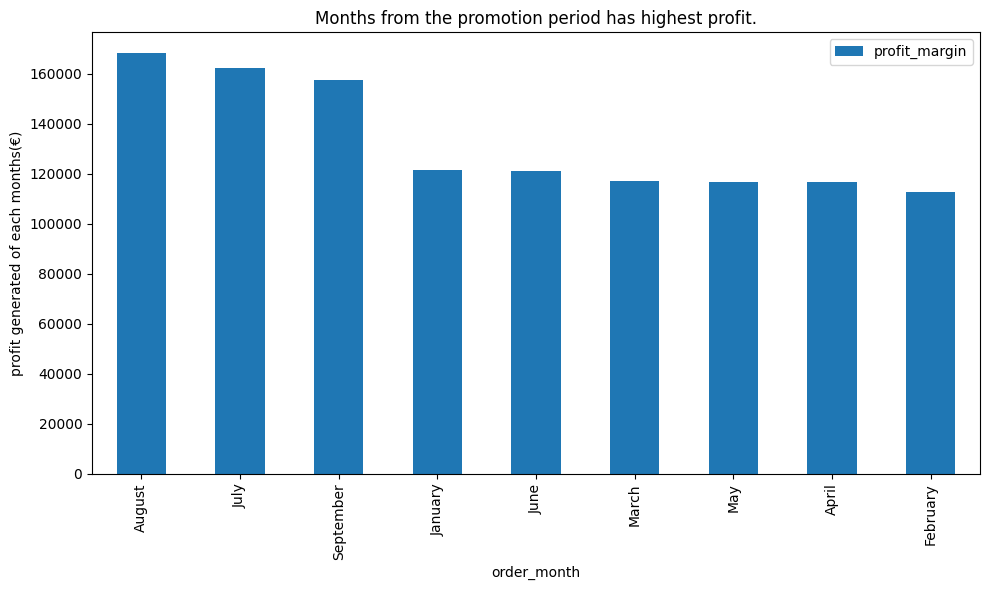

In [176]:
monthly_tot_profit_margin.plot( 
    kind="bar",
    figsize=(10,6),
    y="profit_margin",ylabel="profit generated of each months(€)",x = "tempo_month",title="Months from the promotion period has highest profit.",
    legend=True
    )
plt.tight_layout()
plt.show()

* months of the promotion period generate higher profit.

### * shipping cost distribution during promotion period

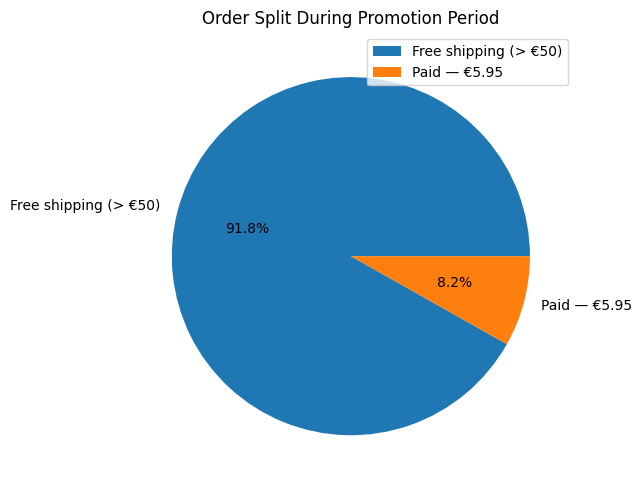

In [185]:
(on_promotion.drop_duplicates('order_id')
             .groupby('shipping_cost')
             .size()
             .rename({0.0: 'Free shipping (> €50)', 5.95: 'Paid — €5.95'})
             .plot(kind='pie', figsize=(6, 5),
                   autopct='%1.1f%%',
                   title='Order Split During Promotion Period',
                   legend=True))
plt.ylabel('')
plt.tight_layout()
plt.show()


* After promotion only 8.2% customers spend less than 50 euros.

* Promotion breakdown across product cost revenue, and net profit 

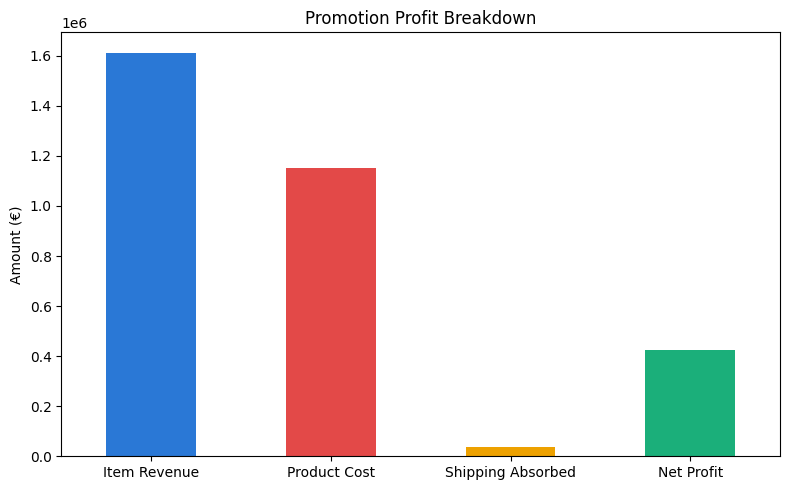

In [178]:
breakdown = pd.Series({
    'Item Revenue':       total_item_revenue,
    'Product Cost':      total_product_cost,
    'Shipping Absorbed': covered_shipping_cost,
    'Net Profit':         net_promo_profit
})

colors = ['#2a78d6', '#e34948', '#eda100', '#1baf7a' if net_promo_profit >= 0 else '#e34948']
breakdown.plot(kind='bar', figsize=(8, 5), color=colors,
               title='Promotion Profit Breakdown',
               ylabel='Amount (€)', xlabel='', legend=False,rot=0)
plt.tight_layout()
plt.show()


* Item Revenue is much higher than the product cost.
* Net Profit is also much higher than the shipping absorbed by the compony.
* This all leads the Promotion brings undeniable profit on the company.

* Category distribution and profit generated

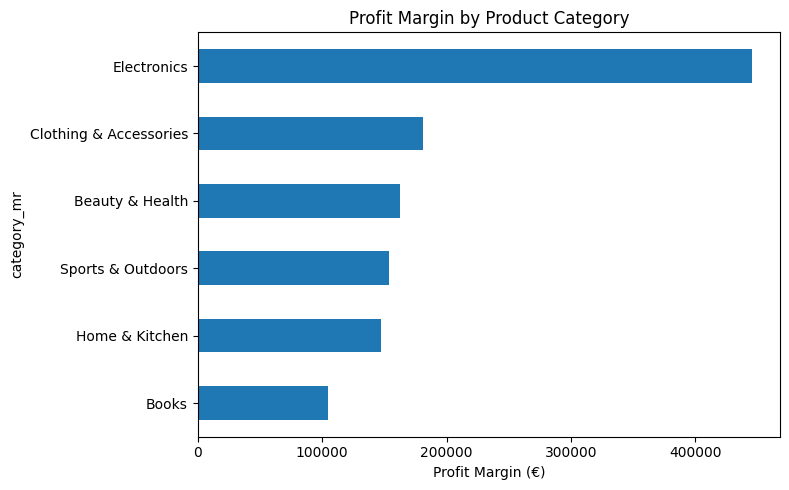

In [179]:
(mr.groupby('category_mr')['profit_margin']
   .sum()
   .sort_values()
   .plot(kind='barh', figsize=(8, 5),
         title='Profit Margin by Product Category',
         xlabel='Profit Margin (€)'))
plt.tight_layout()
plt.show()


* people spending across the two different promotion periods

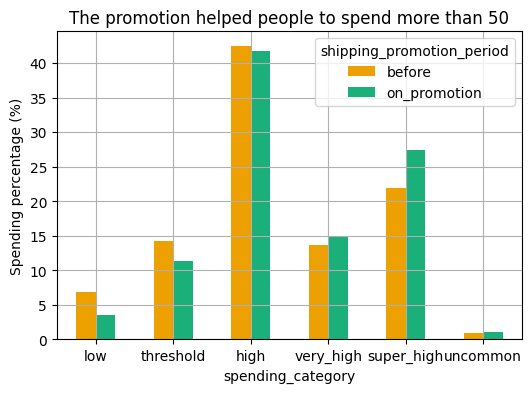

In [180]:
colors = ['#eda100', '#1baf7a']
spending_pcg.plot(
    kind='bar',legend=True,figsize=(6,4),color=colors,
    ylabel="Spending percentage (%)",
    xlabel="spending_category",
    title="The promotion helped people to spend more than 50",
    rot=0,grid=True
    )
plt.show()

* Region distribution across the promotion period.

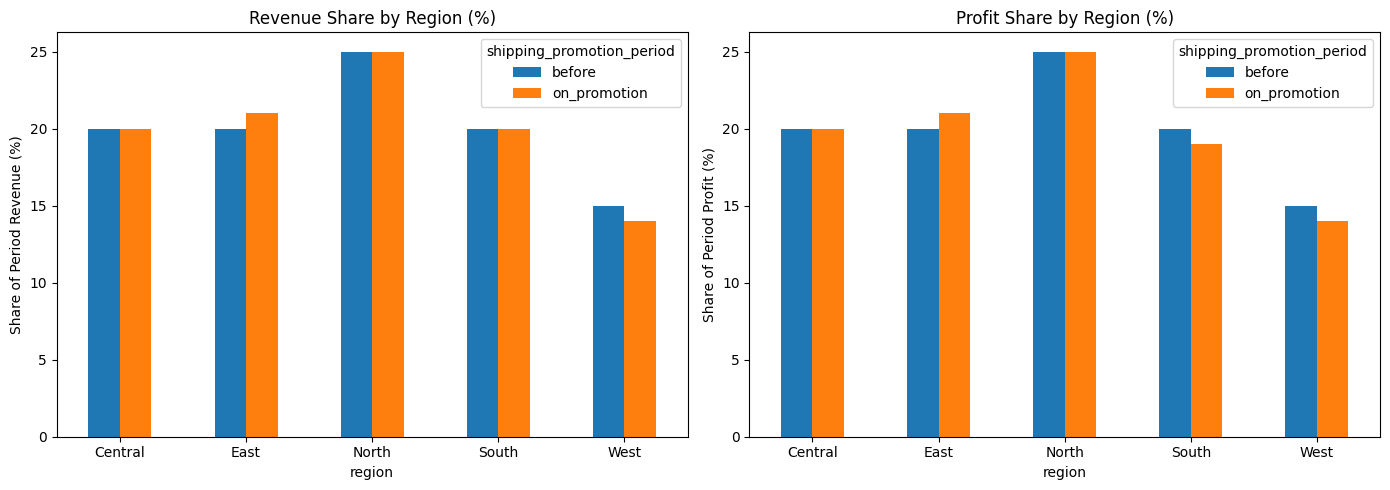

In [181]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

region_rev_pct.plot(kind='bar', ax=ax1, title='Revenue Share by Region (%)',
                    ylabel='Share of Period Revenue (%)', rot=0)

region_profit_pct.plot(kind='bar', ax=ax2, title='Profit Share by Region (%)',
                       ylabel='Share of Period Profit (%)', rot=0)

plt.tight_layout()
plt.show()

---

# conclusion
* Applying the promotion on the shipping cost brings undeniable positive change.
* Promotion period generated 69% of the revenue from previous period.
* 59.43% of orders of the previous period has made during the promotion period. 
* spending of the people has been changed because of the promotion.
* people tend to spent more than 50euros in each order, they made.
* Out of the total cost €1,153,687.99 of the products which has shipped free of charge, `€422,760.18` net profit is generated.
* Only in the 3-months a visible increase on revenue and profit has seen.
* During the promotion period around 60% orders has made.
* And the promotion helps to change the peoples behavior, by increasing their spending plan.